In [1]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 730.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/mvtec_anomaly_detection'
print(os.listdir(path))

['license.txt', 'readme.txt', '.DS_Store', 'bottle', 'screw', 'toothbrush', 'cable', 'grid', 'leather', 'carpet', 'hazelnut', 'tile', 'zipper', 'metal_nut', 'capsule', 'pill', 'transistor', 'wood']


In [5]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"Folder: {item}")

Folder: bottle
Folder: screw
Folder: toothbrush
Folder: cable
Folder: grid
Folder: leather
Folder: carpet
Folder: hazelnut
Folder: tile
Folder: zipper
Folder: metal_nut
Folder: capsule
Folder: pill
Folder: transistor
Folder: wood


### For this dataset, since we are only looking at industrial parts, we will not be considering toothbrush, grid, leather, carpet, hazelnut, and tile

# Bottle

## Training

In [26]:
bottle_path = os.path.join(path, input("What class do you want to train/test? Options are listed above (ex. if you want to train on bottles type 'bottle'.) "))
bottle_train_path = os.path.join(bottle_path, 'train/good')
bottle_images_train = [f for f in os.listdir(bottle_train_path) if f.endswith('.png')]

if bottle_images_train:
    for i in range(0,5):
        image_filename = bottle_images_train[i]
        full_image_path = os.path.join(bottle_train_path, image_filename)
        try:
            img = Image.open(full_image_path)
            print(f"Successfully opened: {image_filename}")
            # Display the image (optional, works in Colab output)
            display(img)
        except FileNotFoundError:
            print(f"Error: Image file not found at {full_image_path}")
        except Exception as e:
            print(f"An error occurred while opening the image: {e}")
else:
    print("No images found in bottle_images_train to open.")

print(f"Contents of 'bottle/train' directory: {os.listdir(bottle_train_path)}")
print(f"Number of image files in 'bottle/train/good': {len(bottle_images_train)}")



Output hidden; open in https://colab.research.google.com to view.

### Define the Encoder

In [27]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

def load_and_preprocess_image(image_path):
  img = Image.open(image_path).convert('RGB')
  img = img.resize((IMG_WIDTH, IMG_HEIGHT))
  img = np.array(img)
  img = img / 255.0 # Normalize to [0,1]
  return img

bottle_images_training_set = []
for img_filename in bottle_images_train:
  full_path = os.path.join(bottle_train_path, img_filename)
  bottle_images_training_set.append(load_and_preprocess_image(full_path))

X_train = np.array(bottle_images_training_set)
print(f"shape of training data: {X_train.shape}")



shape of training data: (240, 128, 128, 3)


### Create UNet Encoder and Decoder

In [28]:
def combined_ssim_mse_loss(y_true, y_pred, alpha=0.84):
    """
    Combined SSIM + MSE loss.
    alpha controls the SSIM weight:
        - alpha=0.84 is common in literature (SSIM emphasized)
        - (1 - alpha) is the MSE weight
    Images must be in [0,1].
    """
    # SSIM returns a value in [-1,1], where 1 = perfect match.
    ssim_loss = 1 - tf.image.ssim(y_true, y_pred, max_val=1.0)

    # MSE encourages exact pixel reconstruction
    mse_loss = tf.reduce_mean(tf.math.squared_difference(y_true, y_pred))

    # Weighted combination
    return alpha * ssim_loss + (1 - alpha) * mse_loss

In [197]:
from tensorflow.keras import layers, models

def build_unet_autoencoder(img_height=IMG_HEIGHT, img_width=IMG_WIDTH, channels=CHANNELS, latent_dim=None):
    inputs = layers.Input(shape=(img_height, img_width, channels))

    # 1. Internal Data Augmentation (Crucial for small datasets)
    # Randomly slightly zoom/shift the input so the model never sees the same pixel grid twice.
    # This prevents memorization/copy-pasting.
    x = layers.RandomZoom(height_factor=0.1, width_factor=0.1)(inputs)
    x = layers.RandomFlip("horizontal")(x)

    # 2. Gaussian Noise (Denoising)
    x = layers.GaussianNoise(0.05)(x)

    # ----- ENCODER (The Compressor) -----
    # We use LeakyReLU for better gradient flow

    # 128 -> 64
    x = layers.Conv2D(32, (3, 3), strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 64 -> 32
    x = layers.Conv2D(64, (3, 3), strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 32 -> 16
    x = layers.Conv2D(128, (3, 3), strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 16 -> 8 (Bottleneck Spatial Dim)
    x = layers.Conv2D(256, (3, 3), strides=2, padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # ----- BOTTLENECK (8x8) -----
    # 8x8x64 = 4096 floats.
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # ----- DECODER (Resize-Convolution) -----
    # Replaces Conv2DTranspose. This is the "Powerful Decoder" technique.
    # It resizes the image (bilinear) then refines it with convolution.

    # 1. 8 -> 16
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 2. 16 -> 32
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 3. 32 -> 64
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 4. 64 -> 128
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Output
    outputs = layers.Conv2D(channels, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs, name="resize_conv_augment_ae")
    return model

### Define Errors and Create Auto-Encoder

In [198]:
import tensorflow as tf

# Pretrained VGG16 feature extractor (no classifier head)
vgg_base = VGG16(include_top=False,
                 weights='imagenet',
                 input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
vgg_base.trainable = False

# Use a mid-deep layer as feature representation (block4_conv3 is common)
feature_extractor = tf.keras.Model(
    inputs=vgg_base.input,
    outputs=vgg_base.get_layer('block4_conv3').output
)

# Multi-scale feature extractor for heatmaps (block3_conv3 ≈ 32x32, block4_conv3 ≈ 16x16)
feature_extractor_multi = tf.keras.Model(
    inputs=vgg_base.input,
    outputs=[
        vgg_base.get_layer('block3_conv3').output,  # higher-res features
        vgg_base.get_layer('block4_conv3').output   # deeper features
    ]
)
feature_extractor_multi.trainable = False


def feature_reconstruction_error(x, x_rec, batch_size=32):
    """
    Per-image reconstruction error in VGG feature space.
    x, x_rec: numpy arrays (N, H, W, 3) in [0, 1].
    Returns: 1D array (N,) of feature-space MSE.
    """
    # VGG16 expects BGR with Imagenet preprocessing; preprocess_input handles this.
    x_pp   = preprocess_input((x * 255.0).astype('float32'))
    xrec_pp = preprocess_input((x_rec * 255.0).astype('float32'))

    f_x   = feature_extractor.predict(x_pp,   batch_size=batch_size, verbose=0)
    f_x_r = feature_extractor.predict(xrec_pp, batch_size=batch_size, verbose=0)

    # MSE in feature space
    feat_err = np.mean((f_x - f_x_r) ** 2, axis=(1, 2, 3))
    return feat_err


In [199]:
# Build the model (No latent_dim parameter needed anymore)
autoencoder_bottle = build_unet_autoencoder(
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    channels=CHANNELS
)

# Compile with your custom loss
autoencoder_bottle.compile(
    optimizer='adam',
    loss=combined_ssim_mse_loss
)

autoencoder_bottle.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "resize_conv_augment_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_6                │ (None, 128, 128, 3)    │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 8, 8, 64)       │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 16, 16, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 32, 32, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,071,811 (4.09 MB)

 Trainable params: 1,071,811 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

In [200]:
import tensorflow as tf
from tensorflow.keras import backend as K

def combined_ssim_mse_loss(y_true, y_pred, alpha=0.84):
    """
    Combined SSIM + MSE loss.
    alpha controls the SSIM weight:
        - alpha=0.84 is common in literature (SSIM emphasized)
        - (1 - alpha) is the MSE weight
    Images must be in [0,1].
    """
    # SSIM returns a value in [-1,1], where 1 = perfect match.
    ssim_loss = 1 - tf.image.ssim(y_true, y_pred, max_val=1.0)

    # MSE encourages exact pixel reconstruction
    mse_loss = tf.reduce_mean(tf.math.squared_difference(y_true, y_pred))

    # Weighted combination
    return alpha * ssim_loss + (1 - alpha) * mse_loss


In [201]:
autoencoder_bottle.compile(optimizer='adam', loss=combined_ssim_mse_loss)

# Train the model
from sklearn.model_selection import train_test_split

# split good images into train (for AE) and validation (for threshold)
X_train_temp, X_val_threshold = train_test_split(
    X_train, test_size=0.1, random_state=42
)

X_train_ae, X_val_ae = train_test_split(
    X_train_temp, test_size=0.2, random_state=42
)


history = autoencoder_bottle.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_ae, X_val_ae)
)

print("Autoencoder training complete.")

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 863ms/step - loss: 0.5090 - val_loss: 0.4847
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 807ms/step - loss: 0.4707 - val_loss: 0.4501
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 810ms/step - loss: 0.4219 - val_loss: 0.3825
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 802ms/step - loss: 0.3583 - val_loss: 0.3296
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 804ms/step - loss: 0.3287 - val_loss: 0.3193
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 803ms/step - loss: 0.3180 - val_loss: 0.3156
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 812ms/step - loss: 0.3090 - val_loss: 0.3164
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 804ms/step - loss: 0.3060 - val_loss: 0.3143
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 809ms/step - loss: 0.3035 - val_loss: 0.3121
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 830ms/step - loss: 0.3022 - val_loss: 0.3107
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 818ms/step - loss: 0.3019 - val_loss: 0.3098
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 844ms/step - loss: 0.3033 - val_lo

## Testing

In [202]:
# Reconstruct AE training images
X_train_reconstructed = autoencoder_bottle.predict(X_train_ae, batch_size=32)

# Reconstruct the HELD-OUT validation set used ONLY for thresholding
X_valthr_reconstructed = autoencoder_bottle.predict(X_val_threshold, batch_size=32)

# VGG feature-space reconstruction errors
feat_errors_train   = feature_reconstruction_error(X_train_ae,      X_train_reconstructed,   batch_size=32)
feat_errors_valthr  = feature_reconstruction_error(X_val_threshold, X_valthr_reconstructed,  batch_size=32)

# Scores: train (for inspection) and held-out validation (for threshold)
train_scores    = feat_errors_train
valthr_scores   = feat_errors_valthr

print(f"Shape of training VGG feature errors: {feat_errors_train.shape}")
print(f"Shape of HELD-OUT validation VGG feature errors: {feat_errors_valthr.shape}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Shape of training VGG feature errors: (172,)
Shape of HELD-OUT validation VGG feature errors: (24,)


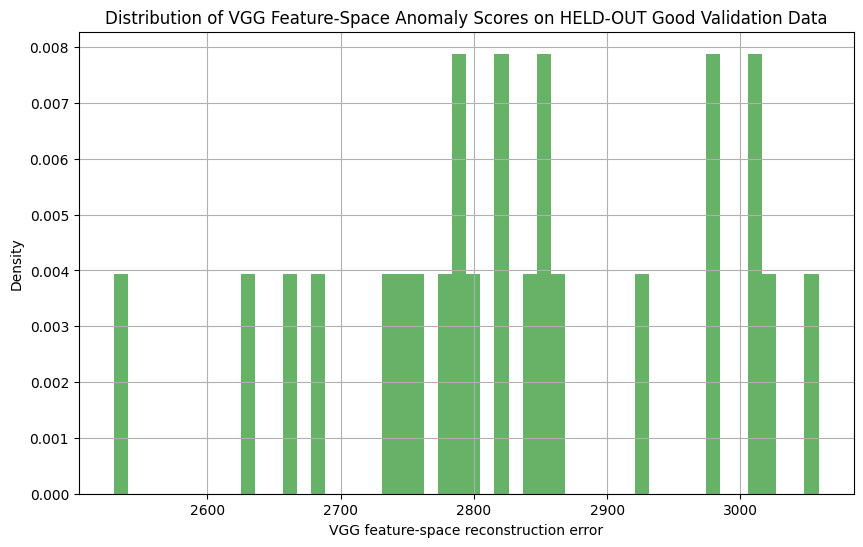

In [203]:
plt.figure(figsize=(10, 6))
plt.hist(
    valthr_scores,
    bins=50,
    density=True,
    alpha=0.6,
    color='g'
)
plt.title('Distribution of VGG Feature-Space Anomaly Scores on HELD-OUT Good Validation Data')
plt.xlabel('VGG feature-space reconstruction error')
plt.ylabel('Density')
plt.grid(True)
plt.show()


In [204]:
bottle_test_path = os.path.join(bottle_path, 'test')
bottle_images_test = []
y_test = []          # 0 = good, 1 = defective

test_subfolders = [f for f in os.listdir(bottle_test_path)
                   if os.path.isdir(os.path.join(bottle_test_path, f))]

for subfolder in test_subfolders:
    subfolder_path = os.path.join(bottle_test_path, subfolder)
    img_files_in_subfolder = [f for f in os.listdir(subfolder_path)
                              if f.lower().endswith('.png')]

    # Ground-truth label: good = 0, everything else = 1
    label = 0 if subfolder == 'good' else 1

    for img_filename in img_files_in_subfolder:
        full_path = os.path.join(subfolder_path, img_filename)
        bottle_images_test.append(load_and_preprocess_image(full_path))
        y_test.append(label)

X_test_bottle = np.array(bottle_images_test)
y_test = np.array(y_test)

print(f"Shape of testing data: {X_test_bottle.shape}")
print(f"Shape of testing labels: {y_test.shape}")

Shape of testing data: (151, 128, 128, 3)
Shape of testing labels: (151,)


In [205]:
X_test_bottle_reconstructed = autoencoder_bottle.predict(X_test_bottle, batch_size=32)
print(f"Shape of reconstructed test data: {X_test_bottle_reconstructed.shape}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step
Shape of reconstructed test data: (151, 128, 128, 3)


In [206]:
X_test_bottle_reconstructed = autoencoder_bottle.predict(X_test_bottle, batch_size=32)
print(f"Shape of reconstructed test data: {X_test_bottle_reconstructed.shape}")

feat_errors_test = feature_reconstruction_error(
    X_test_bottle, X_test_bottle_reconstructed, batch_size=32
)
print(f"Shape of test VGG feature errors: {feat_errors_test.shape}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
Shape of reconstructed test data: (151, 128, 128, 3)
Shape of test VGG feature errors: (151,)


In [207]:
test_scores = feat_errors_test

print("Train scores shape:", train_scores.shape)
print("Held-out val scores shape:", valthr_scores.shape)
print("Test scores shape:",  test_scores.shape)

Train scores shape: (172,)
Held-out val scores shape: (24,)
Test scores shape: (151,)


In [208]:
threshold = np.percentile(valthr_scores, 99)
predictions = (test_scores > threshold).astype(int)


In [209]:
predictions = (test_scores > threshold).astype(int)
def_count = np.sum(predictions) # Count of defective (anomaly) images
good_count = len(predictions) - def_count # Count of good images

print(f"Number of defective images in test set: {def_count}")
print(f"Number of good images in test set: {good_count}")

Number of defective images in test set: 62
Number of good images in test set: 89


In [210]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, predictions)
print(f"Overall test accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
print("Confusion matrix (rows = true, cols = pred):")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, predictions, target_names=["good", "defective"]))

Overall test accuracy: 0.5695
Confusion matrix (rows = true, cols = pred):
[[28  4]
 [61 58]]

Classification report:
              precision    recall  f1-score   support

        good       0.31      0.88      0.46        32
   defective       0.94      0.49      0.64       119

    accuracy                           0.57       151
   macro avg       0.63      0.68      0.55       151
weighted avg       0.80      0.57      0.60       151



In [211]:
good_indices = np.where(predictions == 0)[0]
defective_indices = np.where(predictions == 1)[0]

# Select a few examples from each category
num_examples_per_category = 3
selected_good_indices = np.random.choice(good_indices, min(len(good_indices), num_examples_per_category), replace=False)
selected_defective_indices = np.random.choice(defective_indices, min(len(defective_indices), num_examples_per_category), replace=False)

# Combine and shuffle indices for display
example_indices = np.concatenate((selected_good_indices, selected_defective_indices))
np.random.shuffle(example_indices)

print(f"Selected good image indices: {selected_good_indices}")
print(f"Selected defective image indices: {selected_defective_indices}")

Selected good image indices: [135 116  62]
Selected defective image indices: [ 6  8 98]


Computing global VGG feature-error heatmap statistics...
GLOBAL_MIN: 1872.5258
GLOBAL_MAX: 531767.0


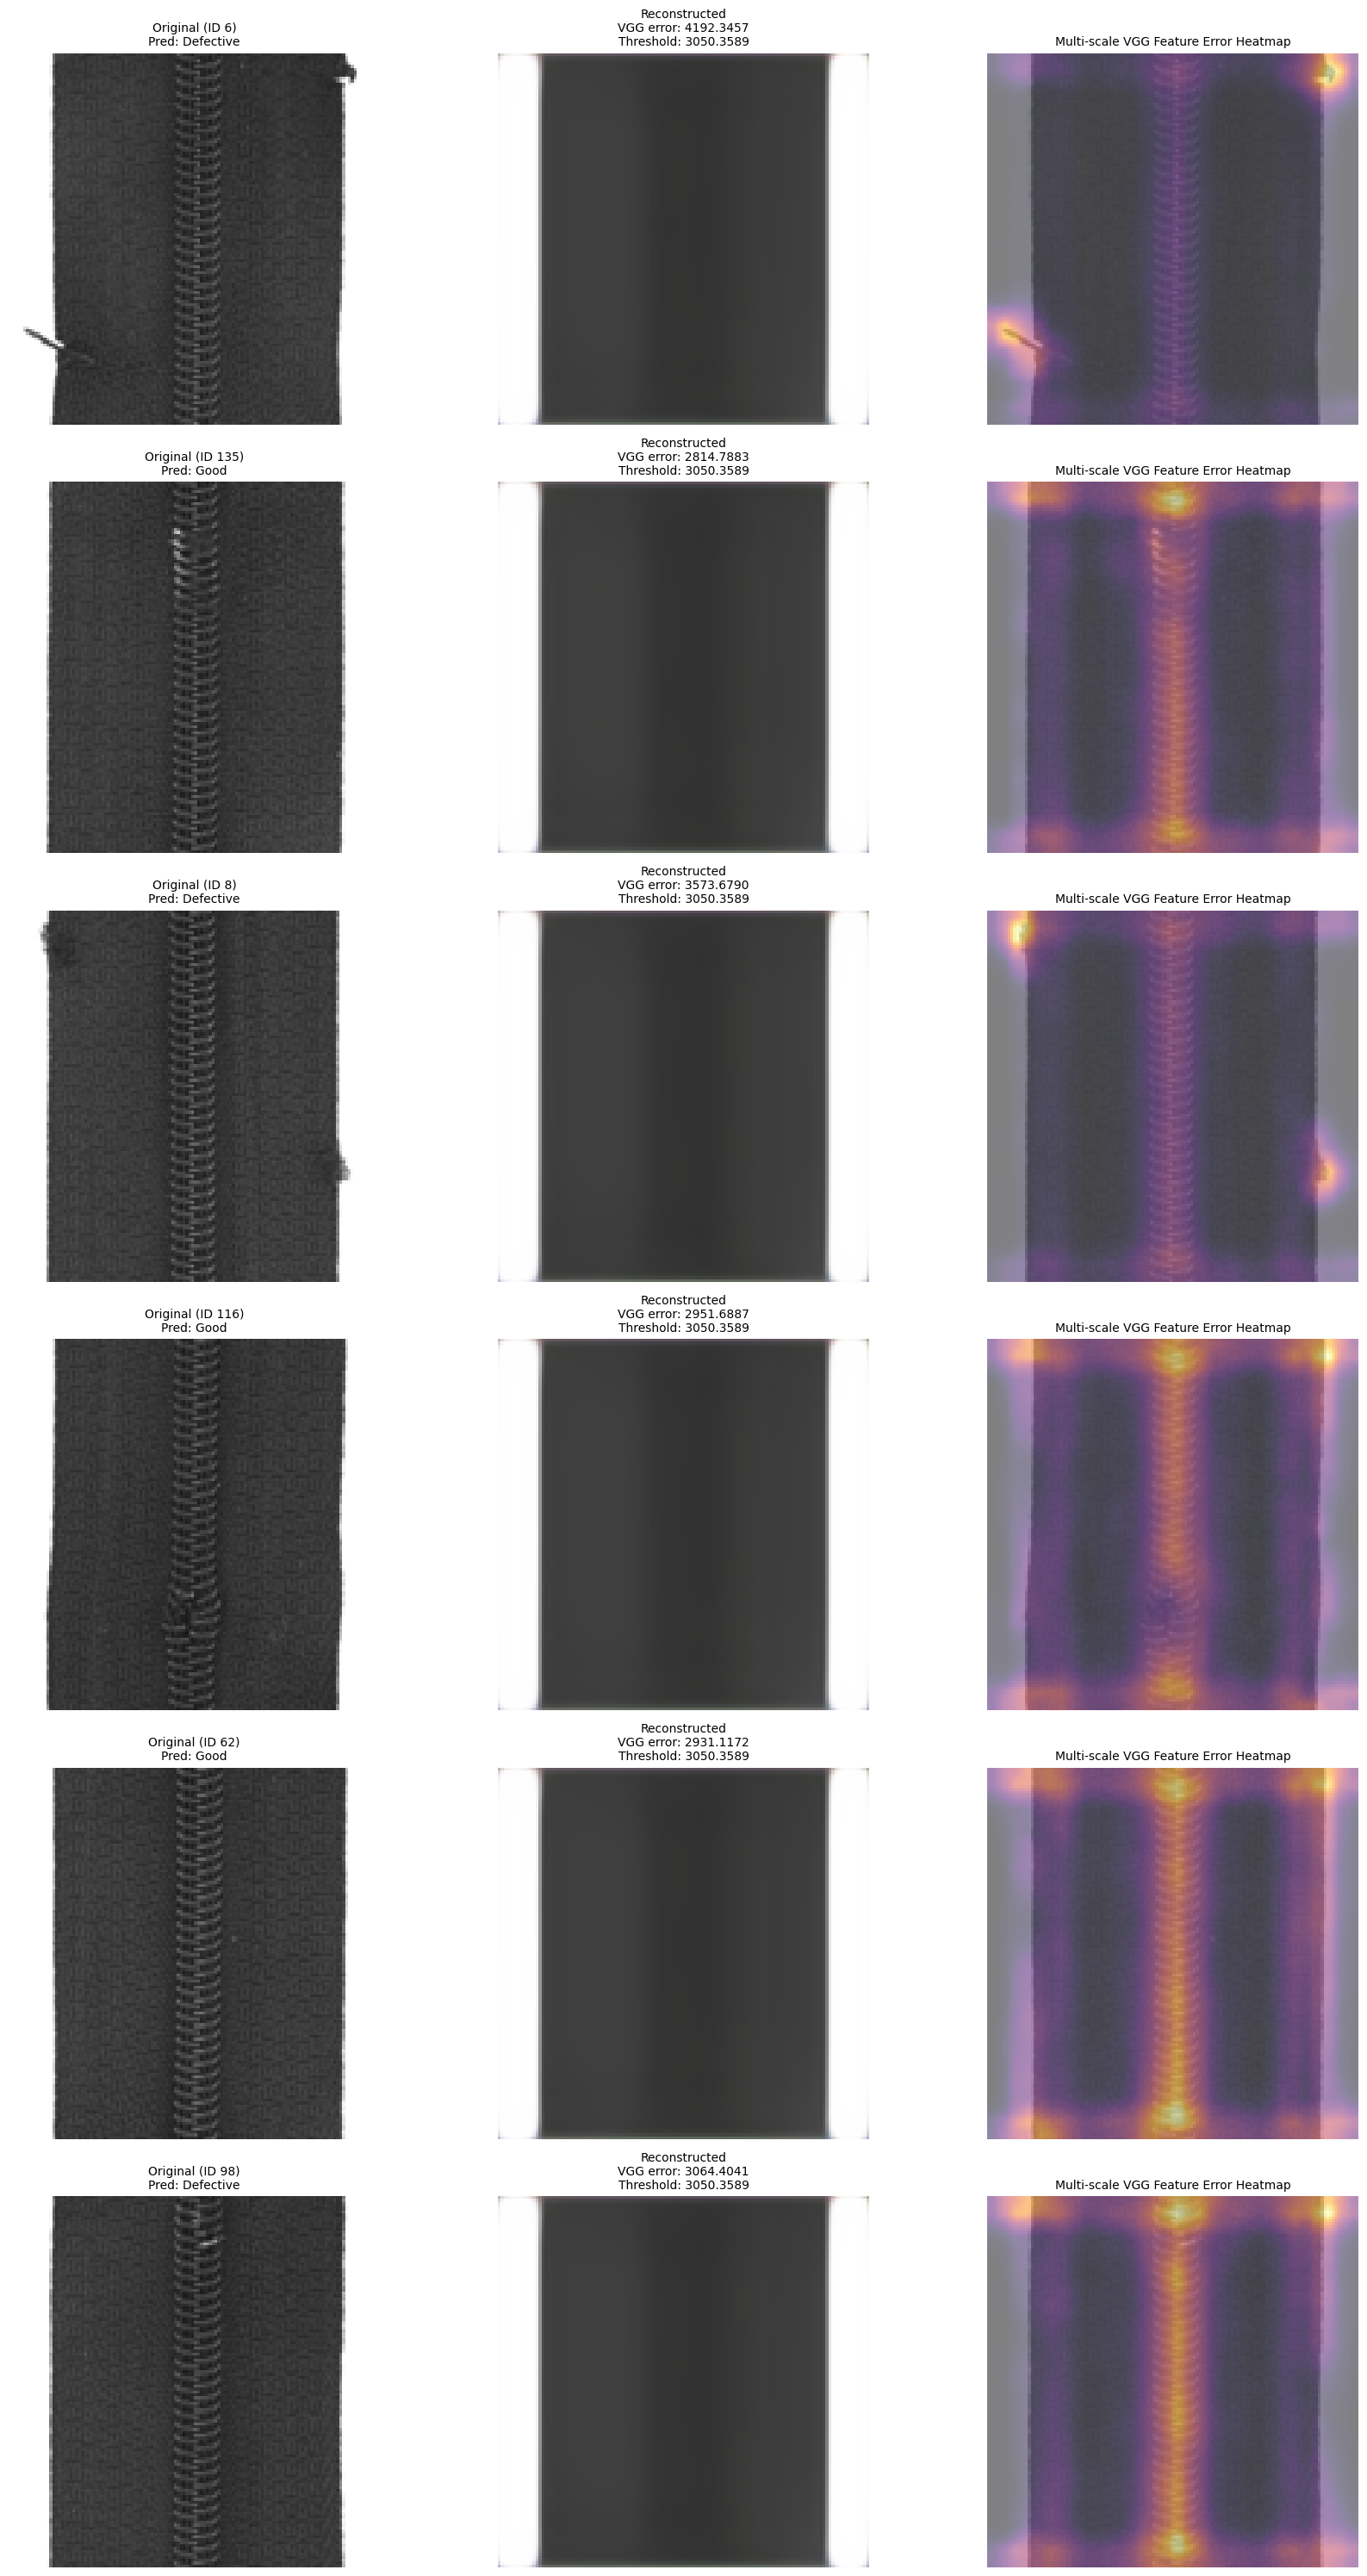

In [212]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Multi-scale VGG Feature Error Heatmap (no normalization here)
# ---------------------------------------------------
def get_feature_error_map(img, img_rec):
    """
    Returns a raw (unnormalized) heatmap at full image resolution.
    img, img_rec are (H, W, 3) arrays in [0,1].
    """
    # preprocess inputs for VGG
    x  = preprocess_input((img * 255.0).astype('float32')[np.newaxis, ...])
    xr = preprocess_input((img_rec * 255.0).astype('float32')[np.newaxis, ...])

    # multi-scale VGG outputs (block3_conv3 ≈32x32, block4_conv3 ≈16x16)
    f3_true, f4_true = feature_extractor_multi.predict(x,  verbose=0)
    f3_rec,  f4_rec  = feature_extractor_multi.predict(xr, verbose=0)

    # compute feature MSE at each scale
    err3 = np.mean((f3_true - f3_rec)**2, axis=-1)[0]   # (H3, W3)
    err4 = np.mean((f4_true - f4_rec)**2, axis=-1)[0]   # (H4, W4)

    # upsample both to input resolution
    err3_up = tf.image.resize(err3[..., None], (IMG_HEIGHT, IMG_WIDTH), method='bilinear').numpy()[..., 0]
    err4_up = tf.image.resize(err4[..., None], (IMG_HEIGHT, IMG_WIDTH), method='bilinear').numpy()[..., 0]

    # combine scales
    err_combined = 0.5 * err3_up + 0.5 * err4_up
    return err_combined   # <-- NO normalization here!


# ---------------------------------------------------
# 2. Compute GLOBAL min/max for normalization
# ---------------------------------------------------
all_err_maps = []

print("Computing global VGG feature-error heatmap statistics...")
for i in range(len(X_test_bottle)):
    img      = X_test_bottle[i]
    img_rec  = X_test_bottle_reconstructed[i]
    err_map  = get_feature_error_map(img, img_rec)
    all_err_maps.append(err_map)

all_err_maps = np.array(all_err_maps)
GLOBAL_MIN = all_err_maps.min()
GLOBAL_MAX = all_err_maps.max()

print("GLOBAL_MIN:", GLOBAL_MIN)
print("GLOBAL_MAX:", GLOBAL_MAX)


# ---------------------------------------------------
# 3. Visualization block (Original, Reconstructed, Heatmap)
# ---------------------------------------------------
plt.figure(figsize=(18, 5 * len(example_indices)))

for i, idx in enumerate(example_indices):
    original_image      = X_test_bottle[idx]
    reconstructed_image = X_test_bottle_reconstructed[idx]
    error               = test_scores[idx]
    classification      = "Defective" if predictions[idx] == 1 else "Good"

    # Original
    plt.subplot(len(example_indices), 3, 3*i + 1)
    plt.imshow(original_image)
    plt.title(f"Original (ID {idx})\nPred: {classification}", fontsize=10)
    plt.axis("off")

    # Reconstructed
    plt.subplot(len(example_indices), 3, 3*i + 2)
    plt.imshow(reconstructed_image)
    plt.title(f"Reconstructed\nVGG error: {error:.4f}\nThreshold: {threshold:.4f}", fontsize=10)
    plt.axis("off")

    # Heatmap (with GLOBAL normalization)
    raw_map = get_feature_error_map(original_image, reconstructed_image)
    heatmap_norm = (raw_map - GLOBAL_MIN) / (GLOBAL_MAX - GLOBAL_MIN + 1e-8)
    heatmap_norm = np.clip(heatmap_norm, 0, 1)

    plt.subplot(len(example_indices), 3, 3*i + 3)
    plt.imshow(original_image, alpha=0.6)
    plt.imshow(heatmap_norm, cmap='inferno', alpha=0.5)
    plt.title("Multi-scale VGG Feature Error Heatmap", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


AI was substantially used to generate all code.